# Three based methods

## Regression Tree
A tree consists of nodes, leaves and branches. At each node a decision is made and two branches branch out of the node. On each level of the tree one predictor X is separated. Therefor for n predictors a n staged tree will build up with n+1 final terminal nodes.

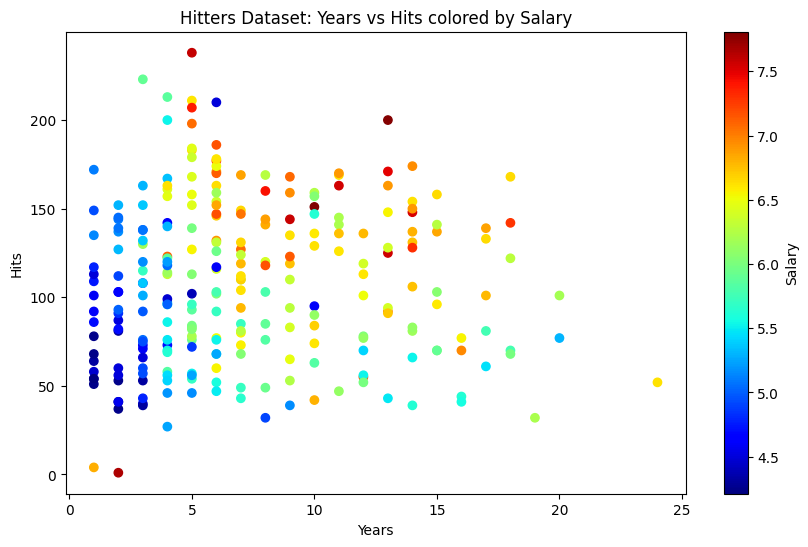

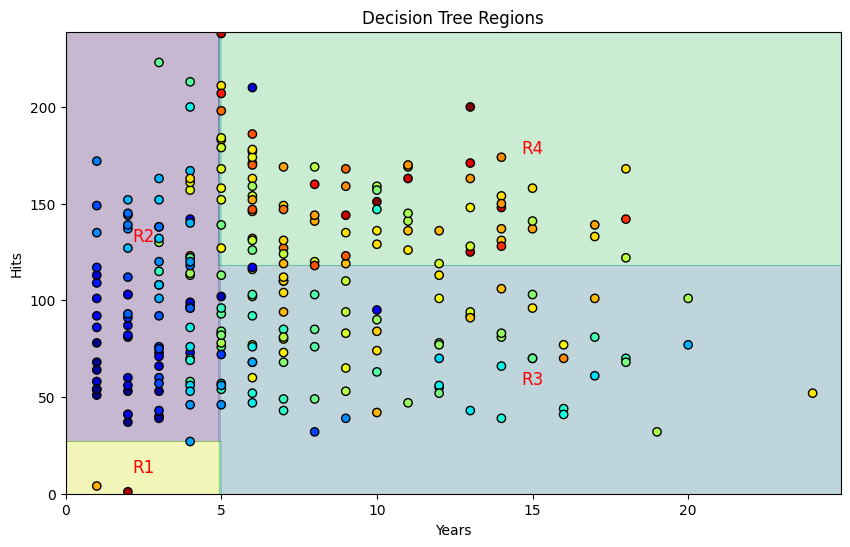

[Years < 5.00]
  [Hits < 27.00]
    Leaf: Predict 7.24
    Leaf: Predict 5.06
  [Hits < 118.00]
    Leaf: Predict 6.00
    Leaf: Predict 6.74


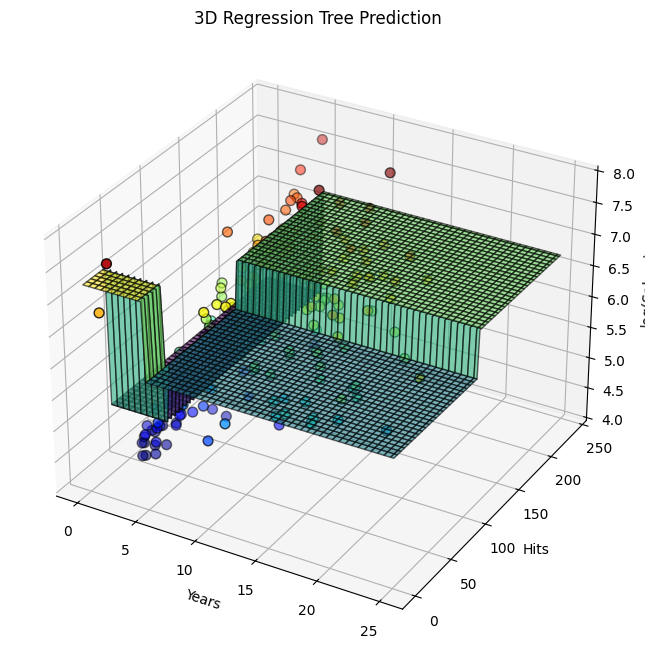

In [1]:
# load the hitters dataset and build a simple tree model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. load the hitters dataset
hitters = pd.read_csv('data/Hitters.csv').dropna()
X1 = hitters[['Years']].values
X2 = hitters[['Hits']].values
y = np.log(hitters['Salary'].values)

# 2. Visualize the data the two predictors and the target as color map jet
plt.figure(figsize=(10, 6))
plt.scatter(X1, X2, c=y, cmap='jet')
plt.colorbar(label='Salary')
plt.xlabel('Years')
plt.ylabel('Hits')
plt.title('Hitters Dataset: Years vs Hits colored by Salary')
plt.show()

# 3. Fit a simple decision tree regressor with max depth 3 from scratch

class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # index of the feature to split on
        self.threshold = threshold  # threshold value for the split
        self.left = left            # left child node
        self.right = right          # right child node
        self.value = value          # predicted value for leaf nodes
class DecisionTreeRegressor:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return TreeNode(value=np.mean(y))

        best_feature, best_threshold = self._best_split(X, y, n_features)
        if best_feature is None:
            return TreeNode(value=np.mean(y))

        left_indices = X[:, best_feature] < best_threshold
        right_indices = X[:, best_feature] >= best_threshold

        left_node = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)

    def _best_split(self, X, y, n_features):
        best_mse = float('inf')
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold

                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                mse = self._calculate_mse(y[left_indices], y[right_indices])
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _calculate_mse(self, left_y, right_y):
        total_samples = len(left_y) + len(right_y)
        if total_samples == 0:
            return 0
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        return (left_mse + right_mse) / total_samples
    
    def predict(self, X):
        return np.array([self._predict_sample(sample, self.root) for sample in X])

    def _predict_sample(self, sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] < node.threshold:
            return self._predict_sample(sample, node.left)
        else:
            return self._predict_sample(sample, node.right)
# 4. Train the decision tree regressor
tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X=np.column_stack((X1, X2)), y=y)

def label_leaf_regions(node, bounds, ax, region_id=[1]):
    """
    Recursively label leaf regions.
    
    bounds = [[x0_min, x0_max], [x1_min, x1_max]]
    """
    if node.value is not None:
        # center of region
        x_center = 0.5 * (bounds[0][0] + bounds[0][1])
        y_center = 0.5 * (bounds[1][0] + bounds[1][1])

        ax.text(
            x_center, y_center,
            f"R{region_id[0]}",
            color="red",
            fontsize=12,
            ha="center",
            va="center"
        )
        region_id[0] += 1
        return

    # split feature and threshold
    f = node.feature
    t = node.threshold

    # left child bounds
    left_bounds = [b.copy() for b in bounds]
    left_bounds[f][1] = t

    # right child bounds
    right_bounds = [b.copy() for b in bounds]
    right_bounds[f][0] = t

    label_leaf_regions(node.left, left_bounds, ax, region_id)
    label_leaf_regions(node.right, right_bounds, ax, region_id)


    # Visualize the decision boundaries
def plot_decision_boundaries(tree, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                        np.arange(y_min, y_max, 0.1))
    Z = tree.predict(np.column_stack((xx.ravel(), yy.ravel())))
    Z = Z.reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="jet")

    initial_bounds = [
        [x_min, x_max],  # Years
        [y_min, y_max]   # Hits
    ]

    label_leaf_regions(tree.root, initial_bounds, ax)

    ax.set_xlabel("Years")
    ax.set_ylabel("Hits")
    ax.set_title("Decision Tree Regions")
    plt.show()

plot_decision_boundaries(tree, np.column_stack((X1, X2)), y)

# Function to print the tree structure
def print_tree(node, feature_names, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Predict {node.value:.2f}")
        return
    print(f"{indent}[{feature_names[node.feature]} < {node.threshold:.2f}]")
    print_tree(node.left, feature_names, depth + 1)
    print_tree(node.right, feature_names, depth + 1)
# Print the tree structure
feature_names = ['Years', 'Hits']
print_tree(tree.root, feature_names)

from graphviz import Digraph 
# set PATH for graphviz if needed
import os
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

def visualize_tree(root, feature_names):
    dot = Digraph()
    counter = {"id": 0}  # mutable global counter

    def add_node(node):
        node_id = str(counter["id"])
        counter["id"] += 1

        if node.value is not None:
            dot.node(node_id, f"Leaf\nValue = {node.value:.2f}")
            return node_id

        label = f"{feature_names[node.feature]} < {node.threshold:.2f}"
        dot.node(node_id, label)

        left_id = add_node(node.left)
        right_id = add_node(node.right)

        dot.edge(node_id, left_id)
        dot.edge(node_id, right_id)

        return node_id

    add_node(root)
    return dot

# Visualize the tree structure
dot = visualize_tree(tree.root, feature_names)
dot.render('decision_tree', format='png', cleanup=True)


from mpl_toolkits.mplot3d import Axes3D  # für 3D-Plot

def plot_tree_3d(tree, X, y):
    # Feature-Räume
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Meshgrid für Z-Vorhersage
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    # Vorhersage für alle Punkte im Grid
    Z = tree.predict(np.column_stack((xx.ravel(), yy.ravel())))
    Z = Z.reshape(xx.shape)

    # 3D-Figur erstellen
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Oberfläche (predicted Z)
    ax.plot_surface(xx, yy, Z, cmap='viridis', alpha=0.6, edgecolor='k')

    # Scatterplot der Trainingsdaten
    ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap='jet', s=50, edgecolor='k')

    ax.set_xlabel('Years')
    ax.set_ylabel('Hits')
    ax.set_zlabel('log(Salary)')
    ax.set_title('3D Regression Tree Prediction')
    plt.show()

# Aufrufen
plot_tree_3d(tree, np.column_stack((X1, X2)), y)


## Observations on Regression Trees

### Partitioning of the Feature Space
A regression tree partitions the predictor space into \( M \) disjoint regions

$$
\mathcal{R}_1, \mathcal{R}_2, \dots, \mathcal{R}_M
$$

such that each region is an **axis-aligned rectangle**.  
Within each region, the prediction is constant.

The fitted regression function can be written as

$$
\hat{f}(x) = \sum_{m=1}^{M} c_m \, \mathbb{1}(x \in \mathcal{R}_m)
$$

where

$$
c_m = \frac{1}{|\mathcal{R}_m|} \sum_{x_i \in \mathcal{R}_m} y_i
$$

---

### Geometry of Decision Boundaries
Each split in a regression tree has the form

$$
X_j < s
$$

Therefore:
- All splits are **axis-aligned**
- Decision boundaries are **piecewise linear**
- Each region is rectangular

As a result, trees approximate complex shapes (e.g. circles) using many small rectangles.

---

### Comparison with Linear Discriminant Analysis (LDA)
- LDA learns a **single global linear boundary**
- Regression trees learn **multiple local linear boundaries**
- Trees are **nonlinear models**, despite linear split rules

---

### Bias–Variance Tradeoff
- Shallow trees: high bias, low variance  
- Deep trees: low bias, high variance  

A fully grown tree typically overfits without regularization.

---

### Regularization in Trees
Regression trees are regularized by structural constraints:
- Maximum depth
- Minimum samples per leaf
- Minimum impurity decrease
- Cost–complexity pruning

No explicit \( $\ell_1$ \) or \( $\ell_2$ \) penalties are used.

---

## Construction of a Regression Tree

### Objective at Each Split
At each node, choose the split that minimizes the residual sum of squares (RSS):

$$
\text{RSS} =
\sum_{x_i \in \mathcal{R}_1} (y_i - \bar{y}_1)^2
+
\sum_{x_i \in \mathcal{R}_2} (y_i - \bar{y}_2)^2
$$

---

### Greedy Recursive Tree-Building Procedure (Detailed)

**Step 1: Start with all training data at the root node**  
- The root node contains **all observations**.  
- The goal is to partition the predictor space into regions where the target variable has **low variance**.

**Step 2: For each predictor $X_j$ and each candidate split point $s$**  
1. **Candidate split points $s$**:  
   - Use **all unique values** of $X_j$ in the current node as potential thresholds.  
   - Alternatively, for efficiency, you can use **midpoints between consecutive sorted values**.  

2. **Split the data into two regions**:  
$$
\mathcal{R}_1 = \{ x : X_j < s \}, \quad
\mathcal{R}_2 = \{ x : X_j \ge s \}
$$

3. **Compute the RSS (Residual Sum of Squares)** for this split:  
$$
RSS = \sum_{x_i \in \mathcal{R}_1} (y_i - \bar{y}_1)^2
    + \sum_{x_i \in \mathcal{R}_2} (y_i - \bar{y}_2)^2
$$  
- Here, $\bar{y}_1$ and $\bar{y}_2$ are the **mean target values** in $\mathcal{R}_1$ and $\mathcal{R}_2$.

**Step 3: Choose the best split**  
- Among all features $X_j$ and candidate thresholds $s$, select the **feature and threshold** that **minimizes $RSS$**.  
- This is the **greedy choice**: it optimizes the split **locally** at the current node, without looking ahead.

**Step 4: Recursively apply the procedure**  
- Repeat Steps 2–3 for the left and right child nodes.  
- At each child node, consider only the data points that fall into that node’s region.

**Step 5: Stop when a stopping criterion is met**  
- Maximum tree depth reached ($\text{max\_depth}$)  
- Too few observations in a node ($\text{min\_samples\_split}$)  
- Optional: minimal decrease in $RSS$ ($\text{min\_impurity\_decrease}$)  

**Step 6: Assign predictions to terminal nodes (leaves)**  
- Each leaf node predicts the **mean target value** of all training observations that fall into that leaf:  
$$
\hat{y}_{\text{leaf}} = \frac{1}{|\mathcal{R}_m|} \sum_{x_i \in \mathcal{R}_m} y_i
$$  
- The result is a **piecewise constant function** over the feature space.


---

## Prediction with a Regression Tree

Given a new observation  \( x \) :

1. Start at the root node  
2. Apply the split rule  \( $ X_j $ < s \)   
3. Move left or right depending on the condition  
4. Repeat until a terminal node is reached  
5. Predict the mean response of that leaf

Formally,

$$
\hat{y}(x) = c_m \quad \text{such that } x \in \mathcal{R}_m
$$
>A single regression tree predicts for a new observation only the mean target value of the leaf region it falls into; therefore, the prediction is **locally constant** and piecewise-constant over the feature space.

---

## Number of Regions
A tree with \( L \) levels (stages) can have at most

$$
2^L
$$

terminal regions (leaves).

The actual number may be smaller due to early stopping or pruning.

---

## Key Takeaways
- Regression trees partition the feature space into axis-aligned rectangles  
- Predictions are constant within each region  
- Trees are flexible but geometrically constrained  
- Complexity is controlled by depth and pruning  
- Trees form the basis of powerful ensemble methods such as Random Forests and Boosting



## Tree Pruning

A fully grown regression tree can be created by repeatedly splitting nodes until each leaf contains only a single observation. While such a tree is extremely flexible and fits the training data almost perfectly, it tends to **overfit** and generalizes poorly to new data.

**Tree pruning** is a method to reduce the size of a fully grown tree in order to improve generalization. The main idea is:

1. Identify branches and leaves that **contribute little** to reducing the test error (or increase the variance without much gain in bias reduction).
2. Remove or collapse these nodes to form a **smaller subtree**.
3. Choose the **optimal subtree** (usually via cross-validation) that achieves a good trade-off between model complexity and prediction error.

Formally, pruning aims to find a subtree $T \subset T_0$ of the full tree $T_0$ that **minimizes a cost-complexity measure**, for example:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

- $R(T)$: error of the tree (e.g., RSS for regression)  
- $|T|$: number of terminal nodes (leaves) in the tree  
- $\alpha$: complexity penalty parameter

By increasing $\alpha$, we penalize larger trees more, resulting in a **simpler tree** with fewer leaves that generalizes better.

### Cost-Complexity Pruning Example

Suppose we have a small regression tree with 4 leaves:

| Leaf | Prediction | RSS Contribution |
|------|------------|----------------|
| R1   | 5          | 2              |
| R2   | 8          | 3              |
| R3   | 6          | 1              |
| R4   | 9          | 4              |

- Total RSS: $R(T_0) = 2 + 3 + 1 + 4 = 10$  
- Number of leaves: $|T_0| = 4$

If we prune leaves R3 and R4 (merge them into their parent):

- New RSS: $R(T_1) = 2 + 3 + 6 = 11$  
- New number of leaves: $|T_1| = 3$

Compute cost-complexity measure $R_\alpha(T) = R(T) + \alpha |T|$:

- For $\alpha = 1$:
  $$
  R_\alpha(T_0) = 10 + 1 \cdot 4 = 14, \quad
  R_\alpha(T_1) = 11 + 1 \cdot 3 = 14
  $$
  → tie, simpler tree might be preferred  

- For $\alpha = 2$:
  $$
  R_\alpha(T_0) = 10 + 2 \cdot 4 = 18, \quad
  R_\alpha(T_1) = 11 + 2 \cdot 3 = 17
  $$
  → pruned tree preferred, larger $\alpha$ favors **smaller trees** that generalize better.

> In  cost complexity pruning the pruning goes always bottom up as the highest flexibility is always in the lowest layer of the tree.

### Building a regression tree with pruning
1. Use recursive binary split to construct a full tree T0 on the training data where in the terminal leave each leave holds only a predetermined minimum set train data pair(s) x,y
2. Apply cost complexity pruning to the large tree in order to obtain a sequence of subtrees as a function of $\alpha$
3. Use Cross validation e.g. K fold cross validation to select the best performing subtree 
4. Redo step 1 and 2 on the chosen subtree and $\alpha$
5. Return the subtree for the best $\alpha$ with lowest test error





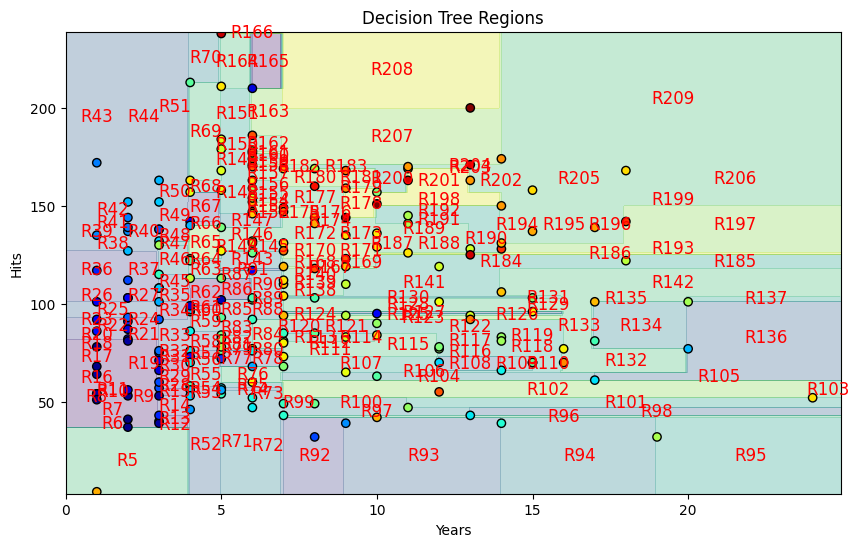

[Years < 5.00]
  [Years < 4.00]
    [Hits < 37.00]
      Leaf: Predict 6.82
      [Hits < 108.00]
        [Hits < 57.00]
          [Years < 3.00]
            [Hits < 56.00]
              [Hits < 54.00]
                [Hits < 51.00]
                  [Hits < 41.00]
                    Leaf: Predict 4.25
                    Leaf: Predict 4.21
                  [Years < 2.00]
                    Leaf: Predict 4.25
                    Leaf: Predict 4.25
                Leaf: Predict 4.27
              Leaf: Predict 4.50
            [Hits < 40.00]
              Leaf: Predict 4.32
              [Hits < 53.00]
                [Hits < 43.00]
                  Leaf: Predict 4.50
                  Leaf: Predict 4.79
                Leaf: Predict 4.32
          [Years < 3.00]
            [Hits < 82.00]
              [Years < 2.00]
                [Hits < 68.00]
                  Leaf: Predict 4.32
                  [Hits < 78.00]
                    Leaf: Predict 4.25
                    Leaf: P

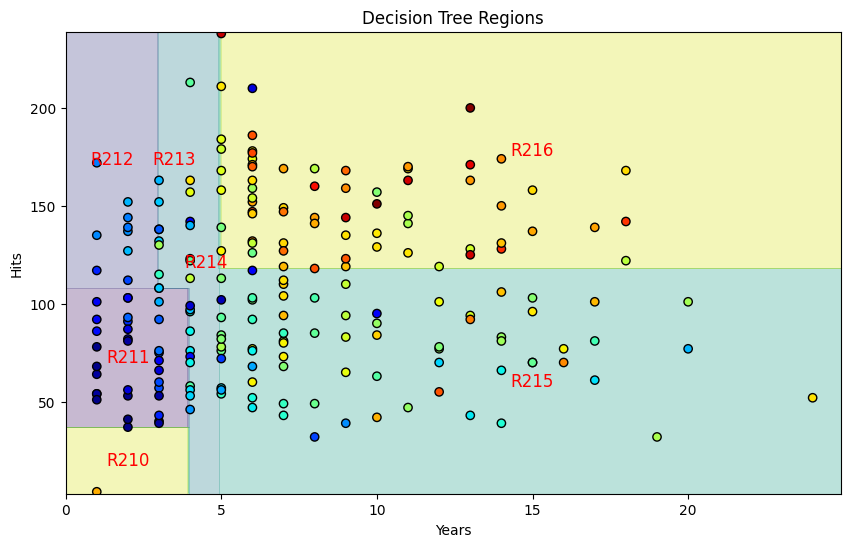

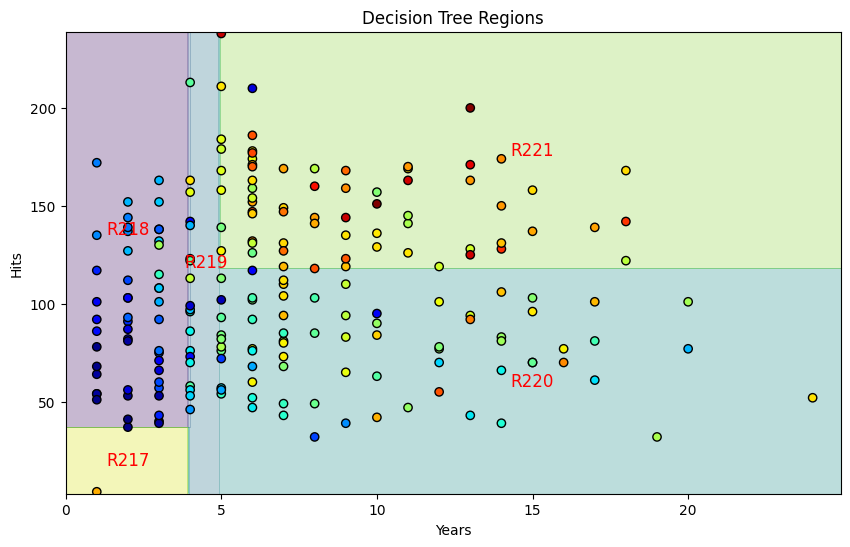

[Years < 5.00]
  [Years < 4.00]
    [Hits < 37.00]
      Leaf: Predict 6.82
      Leaf: Predict 4.84
    Leaf: Predict 5.51
  [Hits < 118.00]
    Leaf: Predict 5.98
    Leaf: Predict 6.63


In [2]:
## Now expand the tree class with cost complexity pruning and try it on the hitters dataset

#1. load the hitters dataset
hitters = pd.read_csv('data/Hitters.csv').dropna()
# lets use more features now
X1 = hitters[['Years']].values
X2 = hitters[['Hits']].values
X3 = hitters[['HmRun']].values
X4 = hitters[['Runs']].values
X5 = hitters[['RBI']].values
y = np.log(hitters['Salary'].values)

# split into training and validation set for cross validation pruning
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    np.column_stack((X1, X2, X3, X4, X5)), y, test_size=0.2, random_state=42
)



# copy the tree class and add cost complexity pruning methods to the class
import numpy as np

class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # index of feature used for split
        self.threshold = threshold  # threshold value for split
        self.left = left            # left child
        self.right = right          # right child
        self.value = value          # prediction if leaf

class DecisionTreeRegressor:
    def __init__(self, max_depth=1000, min_samples_split=2):
        """
        Fully grown regression tree with optional pruning.

        Parameters:
        - max_depth: maximum depth of the tree (default: very large)
        - min_samples_split: minimum number of samples to allow a split
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    # ----------------- Tree Building -----------------
    def fit(self, X, y):
        """Build a fully grown tree from training data"""
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape

        # Stop splitting if max depth reached or too few samples
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return TreeNode(value=np.mean(y))

        # Find best split
        best_feature, best_threshold = self._best_split(X, y, n_features)
        if best_feature is None:
            return TreeNode(value=np.mean(y))

        left_indices = X[:, best_feature] < best_threshold
        right_indices = X[:, best_feature] >= best_threshold

        # Recursively build left and right children
        left_node = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)

    def _best_split(self, X, y, n_features):
        best_mse = float('inf')
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold

                # Skip splits creating empty leaves
                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue

                mse = self._calculate_mse(y[left_indices], y[right_indices])
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _calculate_mse(self, left_y, right_y):
        total_samples = len(left_y) + len(right_y)
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        return (left_mse + right_mse) / total_samples

    # ----------------- Prediction -----------------
    def predict(self, X):
        return np.array([self._predict_sample(sample, self.root) for sample in X])

    def _predict_sample(self, sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] < node.threshold:
            return self._predict_sample(sample, node.left)
        else:
            return self._predict_sample(sample, node.right)

    # ----------------- Cost-Complexity Pruning -----------------
# ----------------- Cost-Complexity Pruning -----------------
# ----------------- Cost-Complexity Pruning -----------------
    def prune(self, alpha=0.0, X_val=None, y_val=None):
        """
        Bottom-up cost-complexity pruning.

        Definitions:
        - R(T)   : RSS of subtree T on validation data
        - |T|    : number of terminal nodes (leaves) in subtree T
        - α      : complexity penalty
        - R_α(T) = R(T) + α |T|

        Pruning rule:
        Collapse node t if
            R(t) + α <= R(T_t) + α |T_t|
        # This pruning method is simplified! Check the next cell for correct and full implementation.
        """

        # -------- Helper: count terminal nodes --------
        def _count_leaves(node):
            if node.value is not None:
                return 1
            return _count_leaves(node.left) + _count_leaves(node.right)

        # -------- Recursive bottom-up pruning --------
        def _prune_node(node, Xv, yv):
            # Leaf: nothing to prune
            if node.value is not None:
                return

            # Route validation data to children
            left_mask = Xv[:, node.feature] < node.threshold
            X_left, y_left = Xv[left_mask], yv[left_mask]
            X_right, y_right = Xv[~left_mask], yv[~left_mask]

            # Prune children first (bottom-up)
            _prune_node(node.left, X_left, y_left)
            _prune_node(node.right, X_right, y_right)

            # If no validation data reaches this node, skip pruning
            if len(yv) == 0:
                return

            # -------- Error of subtree T_t --------
            y_pred_subtree = np.array([
                self._predict_sample(x, node) for x in Xv
            ])
            R_T = np.sum((yv - y_pred_subtree) ** 2)

            # -------- Error if collapsed to a leaf t --------
            c_t = np.mean(yv)
            R_t = np.sum((yv - c_t) ** 2)

            # -------- Tree complexity --------
            T_leaves = _count_leaves(node)

            # -------- Cost-complexity comparison --------
            cost_subtree = R_T + alpha * T_leaves
            cost_collapsed = R_t + alpha

            # -------- Prune if beneficial --------
            if cost_collapsed <= cost_subtree:
                node.left = None
                node.right = None
                node.feature = None
                node.threshold = None
                node.value = c_t

        # Start pruning from the root
        _prune_node(self.root, X_val, y_val)

# 4. Train the decision tree regressor T0
tree = DecisionTreeRegressor(max_depth=1E6)
X_train_reduced = X_train[:, :2]
tree.fit(X=X_train_reduced, y=y_train)
X_val_reduced = X_val[:, :2]


# Visualize the decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# 
# Function to print the tree structure
def print_tree(node, feature_names, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Predict {node.value:.2f}")
        return
    print(f"{indent}[{feature_names[node.feature]} < {node.threshold:.2f}]")
    print_tree(node.left, feature_names, depth + 1)
    print_tree(node.right, feature_names, depth + 1)
# Print the tree structure
feature_names = ['Years', 'Hits', 'HmRun', 'Runs', 'RBI']
print_tree(tree.root, feature_names)

# now we can try to prune the tree based on cost complexity pruning
tree.prune(alpha=0.4, X_val=X_val_reduced, y_val=y_val)

# Plot the pruned tree decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# Print the pruned tree structure
#print_tree(tree.root, feature_names)

# now we can try to prune the tree based on cost complexity pruning
tree.prune(alpha=1.5, X_val=X_val_reduced, y_val=y_val)

# Plot the pruned tree decision boundaries
plot_decision_boundaries(tree, X_train_reduced, y_train)

# Print the pruned tree structure
print_tree(tree.root, feature_names)








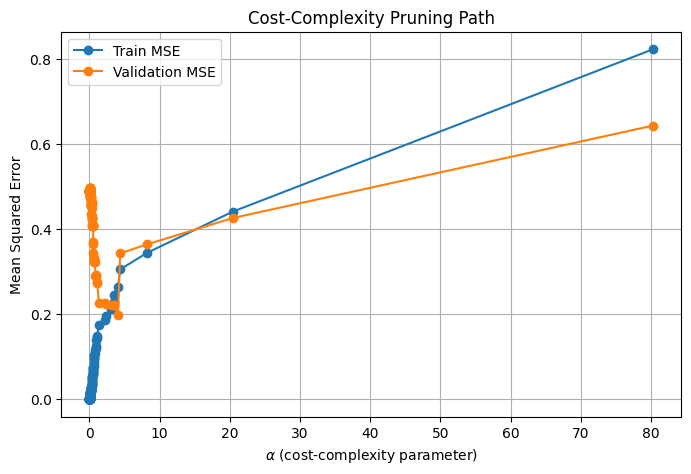

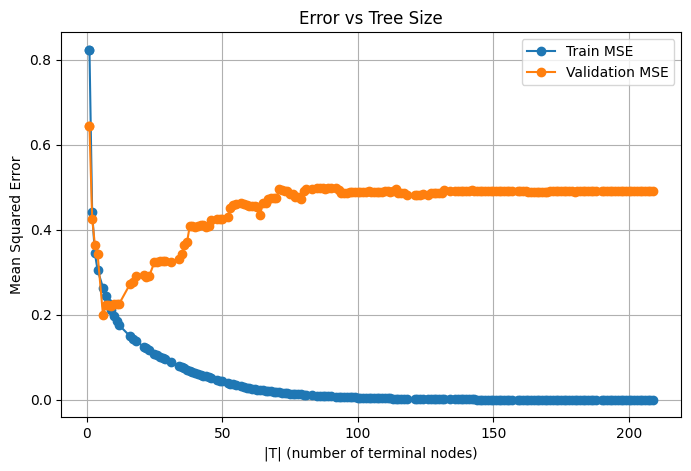

In [3]:
# ============================================================
#  COST-COMPLEXITY PRUNING (CART) IMPLEMENTATION
# ============================================================

import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Load Hitters dataset
# ------------------------------------------------------------
hitters = pd.read_csv('data/Hitters.csv').dropna()

X = hitters[['Years', 'Hits', 'HmRun', 'Runs', 'RBI']].values
y = np.log(hitters['Salary'].values)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 2. Tree Node definition (CART statistics)
# ------------------------------------------------------------
class TreeNode:
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None

        self.value = None

        # CART bookkeeping
        self.n_samples = 0
        self.rss = 0.0
        self.subtree_rss = 0.0
        self.n_leaves = 1

# ------------------------------------------------------------
# 3. Decision Tree Regressor (fully grown)
# ------------------------------------------------------------
class DecisionTreeRegressor:
    def __init__(self, min_samples_split=2):
        self.min_samples_split = min_samples_split
        self.root = None

    # ---------------- Tree growing ----------------
    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y):
        node = TreeNode()
        node.n_samples = len(y)
        node.value = np.mean(y)
        node.rss = np.sum((y - node.value) ** 2)

        if len(y) < self.min_samples_split:
            node.subtree_rss = node.rss
            node.n_leaves = 1
            return node

        best_feature, best_threshold = self._best_split(X, y)

        if best_feature is None:
            node.subtree_rss = node.rss
            node.n_leaves = 1
            return node

        node.feature = best_feature
        node.threshold = best_threshold

        mask = X[:, best_feature] < best_threshold
        node.left = self._build_tree(X[mask], y[mask])
        node.right = self._build_tree(X[~mask], y[~mask])

        node.subtree_rss = node.left.subtree_rss + node.right.subtree_rss
        node.n_leaves = node.left.n_leaves + node.right.n_leaves

        return node

    def _best_split(self, X, y):
        best_rss = np.inf
        best_feature, best_threshold = None, None

        for j in range(X.shape[1]):
            # Try all unique thresholds along feature j
            for t in np.unique(X[:, j]):
                mask = X[:, j] < t
                if mask.sum() == 0 or (~mask).sum() == 0:
                    continue

                y_l, y_r = y[mask], y[~mask]
                # var (y) = 1/n * sum((y - mean(y))^2)
                # rss = sum((y - mean(y))^2)
                # --> var (y) * n is rss
                rss = (
                    np.var(y_l) * len(y_l) +
                    np.var(y_r) * len(y_r)
                )

                if rss < best_rss:
                    best_rss = rss
                    best_feature = j
                    best_threshold = t

        return best_feature, best_threshold

    # ---------------- Prediction ----------------
    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_one(self, x, node):
        if node.left is None and node.right is None:
            # Leaf node reached
            return node.value
        if x[node.feature] < node.threshold:
            # recurse left step down the tree
            return self._predict_one(x, node.left)
        # recurse right step down the tree
        return self._predict_one(x, node.right)

    # ---------------- Cost-Complexity Pruning ----------------
    def _compute_alpha(self, node):
        if node.left is None or node.right is None:
            return np.inf
        # compute alpha = (R(t) - R(T_t)) / (|T_t| - 1)
        # In ISL notation: Sum m=1 T Sum xi E RM (yi - yhatRM)
        return (node.rss - node.subtree_rss) / (node.n_leaves - 1)

    def _find_weakest_link(self, node):
        if node.left is None or node.right is None:
            return None, np.inf

        best_node = node
        best_alpha = self._compute_alpha(node)

        for child in [node.left, node.right]:
            # Recurse into child nodes to find weakest link
            candidate, alpha = self._find_weakest_link(child)
            if alpha < best_alpha:
                best_node = candidate
                best_alpha = alpha

        return best_node, best_alpha
    
    def _recompute_subtree_stats(self, node):
        if node.left is None and node.right is None:
            node.subtree_rss = node.rss
            node.n_leaves = 1
            return node.subtree_rss, node.n_leaves

        rss_l, leaves_l = self._recompute_subtree_stats(node.left)
        rss_r, leaves_r = self._recompute_subtree_stats(node.right)

        node.subtree_rss = rss_l + rss_r
        node.n_leaves = leaves_l + leaves_r

        return node.subtree_rss, node.n_leaves


    def _prune_node(self, node):
        # Collapse node into a leaf by removing its children
        node.left = None
        node.right = None
        node.feature = None
        node.threshold = None
        node.subtree_rss = node.rss # since now a leaf we have subtree rss = rss
        node.n_leaves = 1

    def cost_complexity_pruning_path(self):
        path = []
        tree = deepcopy(self)

        while True:
            if tree.root.left is None and tree.root.right is None:
                # we reached the root only tree
                break
            node, alpha = tree._find_weakest_link(tree.root)
            if node is None:
                break
            tree._prune_node(node) # prune the weakest link
            tree._recompute_subtree_stats(tree.root) # update stats after pruning to ensure correctness of number of leaves etc.
            path.append((alpha, deepcopy(tree))) # store the pruned tree and alpha


        path.append((np.inf, deepcopy(tree)))
        return path

# ------------------------------------------------------------
# 4. Train tree and compute CCP path
# ------------------------------------------------------------
tree = DecisionTreeRegressor(min_samples_split=2)
tree.fit(X_train, y_train)

ccp_path = tree.cost_complexity_pruning_path()

# ------------------------------------------------------------
# 5. Evaluation: Train / Validation MSE
# ------------------------------------------------------------
alphas = []
train_mse = []
val_mse = []
num_leaves = []

for alpha, t in ccp_path:
    alphas.append(alpha)
    num_leaves.append(t.root.n_leaves)

    train_mse.append(np.mean((y_train - t.predict(X_train)) ** 2))
    val_mse.append(np.mean((y_val - t.predict(X_val)) ** 2))

# ------------------------------------------------------------
# 6. Plot: MSE vs Alpha
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(alphas, train_mse, label='Train MSE', marker='o')
plt.plot(alphas, val_mse, label='Validation MSE', marker='o')
plt.xlabel(r'$\alpha$ (cost-complexity parameter)')
plt.ylabel('Mean Squared Error')
plt.title('Cost-Complexity Pruning Path')
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 7. Plot: MSE vs Number of Terminal Nodes |T|
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(num_leaves, train_mse, label='Train MSE', marker='o')
plt.plot(num_leaves, val_mse, label='Validation MSE', marker='o')
plt.xlabel('|T| (number of terminal nodes)')
plt.ylabel('Mean Squared Error')
plt.title('Error vs Tree Size')
plt.legend()
plt.grid(True)
plt.show()


## Classification Tree 

For now we looked into the regression tree where the we used the rss error to decide based on which $X_j$ we split and at which value of s in $X_j$ we split. After growing the tree we used this decision boundries to make regressions by moving based on a new observation $X$ through the tree downwards until we find a terminal leave. Then we predict the average $Y$ of all train data which are associated to this leave. 

In classification we want to predict not a regression variable but the propability of an event belonging to a categoric class variable. To build such a classification tree where at the terminal nodes a class label is found instead of a mean Y of a regression we can use the same tree growing idea as before but we need to adjust the splitting criteria as we now want to split based on the class propability $\hat p_{mk}$, the proportion of training observation in the mth region (Rember R1... Rm) which belong to a certain class vs all observations in this split. 

To minimize the error we use the *Gini index* which is calculated as follows

$$
G = \Sigma_{k=1}^K \hat p_{mk} (1-\hat p_{mk}).
$$

It is a measure of total variance over K classes the index will be close to 0 for $\hat p_{mk}$ close to 0 or 1. Therefor a gini index close to 0 shows a high node purity which means the node contains only samples from one class K, which is a good splitting criterion between two sets $R$ to maximize discrimnation between the classes. Another measure is the entropy 
$$
D = - \Sigma_{k=1}^K \hat p_{mk} log(\hat p_{mk}).

$$ 

both metrics are quite related. 

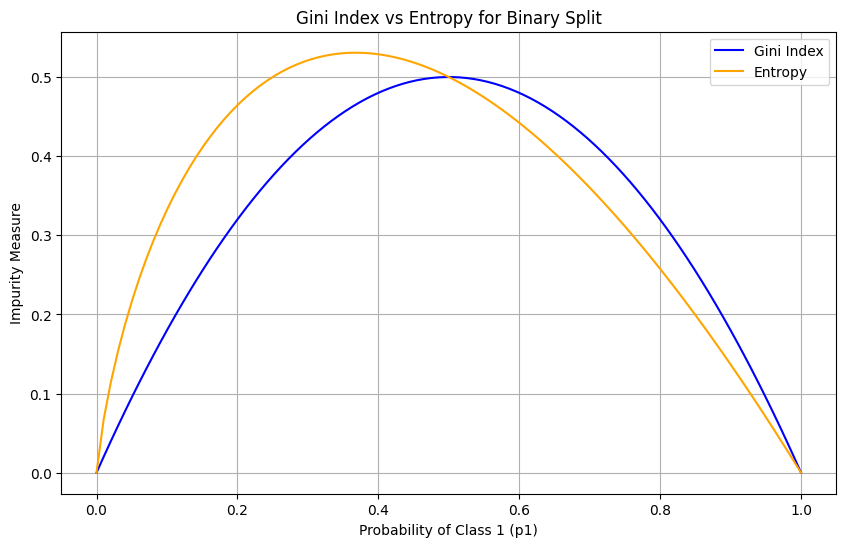

In [4]:
## Plotting the gini index and entropy for a single binary split

import numpy as np
import matplotlib.pyplot as plt
# Define probabilities for class 1
p1 = np.linspace(0, 1, 100)

# Gini index
gini =  2 * p1 * (1 - p1)
# Entropy
D = - p1 * np.log2(p1 + 1e-10) #- (1 - p1) * np.log2(1 - p1 + 1e-10)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(p1, gini, label='Gini Index', color='blue')
plt.plot(p1, D, label='Entropy', color='orange')
plt.xlabel('Probability of Class 1 (p1)')
plt.ylabel('Impurity Measure')
plt.title('Gini Index vs Entropy for Binary Split')
plt.legend()
plt.grid()
plt.show()

Training Accuracy: 99.34%
[Age < 55.00]
  [Sex < 1.00]
    [Chol < 341.00]
      [Chol < 305.00]
        Leaf: Predict class 0
        [Chol < 306.00]
          Leaf: Predict class 1
          Leaf: Predict class 0
      Leaf: Predict class 1
    [Chol < 264.00]
      [Chol < 175.00]
        [Chol < 167.00]
          [Age < 49.00]
            Leaf: Predict class 0
            Leaf: Predict class 1
          Leaf: Predict class 1
        [Chol < 257.00]
          [Age < 46.00]
            [Age < 41.00]
              [Chol < 219.00]
                [Chol < 198.00]
                  Leaf: Predict class 0
                  [Chol < 199.00]
                    Leaf: Predict class 1
                    Leaf: Predict class 0
                [Age < 38.00]
                  Leaf: Predict class 0
                  Leaf: Predict class 1
              [Chol < 203.00]
                [Age < 43.00]
                  Leaf: Predict class 0
                  Leaf: Predict class 1
                [Chol <

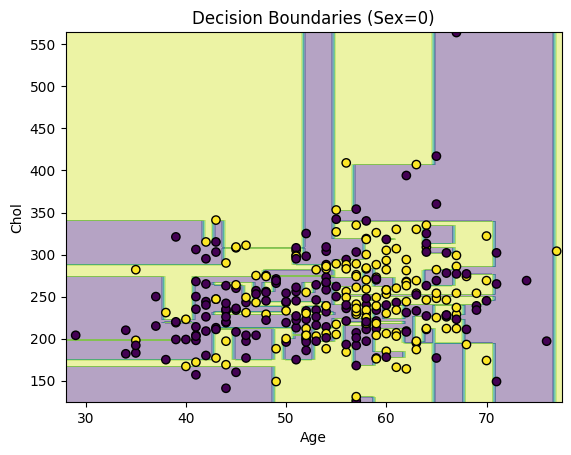

In [5]:
## Lets construct a simiple classification tree from scratch
# Use the Heart Disease dataset from UCI repository

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Heart Disease dataset
data = pd.read_csv('data/Heart.csv')
X = data[['Age', 'Chol', 'Sex']].values
y = data['AHD']  # binary target: No/Yes
y = np.where(y == 'Yes', 1, 0)  # convert to 0/1

# Build a simple decision tree classifier from scratch 
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # index of the feature to split on
        self.threshold = threshold  # threshold value for the split
        self.left = left            # left child node
        self.right = right          # right child node
        self.value = value          # predicted class for leaf nodes
class DecisionTreeClassifier:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)
    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        num_classes = len(np.unique(y))
        if depth >= self.max_depth or n_samples < self.min_samples_split or num_classes == 1:
            # Leaf node: assign majority class
            majority_class = np.bincount(y).argmax()
            return TreeNode(value=majority_class)
        best_feature, best_threshold = self._best_split(X, y, n_features)
        if best_feature is None:
            majority_class = np.bincount(y).argmax()
            return TreeNode(value=majority_class)
        left_indices = X[:, best_feature] < best_threshold
        right_indices = X[:, best_feature] >= best_threshold
        left_node = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_node = self._build_tree(X[right_indices], y[right_indices], depth + 1)
        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)
    def _best_split(self, X, y, n_features):
        best_gini = float('inf')
        best_feature, best_threshold = None, None
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = X[:, feature] >= threshold
                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue
                gini = self._calculate_gini(y[left_indices], y[right_indices])
                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold
    def _calculate_gini(self, left_y, right_y):
        total_samples = len(left_y) + len(right_y)
        gini = 0.0
        for y_subset in [left_y, right_y]:
            if len(y_subset) == 0:
                continue
            class_probs = np.bincount(y_subset) / len(y_subset)
            gini_subset = 1.0 - np.sum(class_probs ** 2)
            gini += (len(y_subset) / total_samples) * gini_subset
        return gini
    def predict(self, X):
        return np.array([self._predict_sample(sample, self.root) for sample in X])
    def _predict_sample(self, sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] < node.threshold:
            return self._predict_sample(sample, node.left)
        else:
            return self._predict_sample(sample, node.right)
# Train the decision tree classifier
tree = DecisionTreeClassifier(max_depth=20)
tree.fit(X, y)
# Predict on training data
y_pred = tree.predict(X)
# Calculate accuracy
accuracy = np.mean(y_pred == y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

# Function to print the tree structure
def print_tree(node, feature_names, depth=0):
    indent = "  " * depth
    if node.value is not None:
        print(f"{indent}Leaf: Predict class {node.value}")
        return
    print(f"{indent}[{feature_names[node.feature]} < {node.threshold:.2f}]")
    print_tree(node.left, feature_names, depth + 1)
    print_tree(node.right, feature_names, depth + 1)
# Print the tree structure
feature_names = ['Age', 'Chol', 'Sex']
print_tree(tree.root, feature_names)

# Plot the decision boundaries for Age and Cholesterol sex fixed 
def plot_decision_boundaries(tree, X, y, sex_value=0):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.5),
        np.arange(y_min, y_max, 0.5)
    )

    sex = np.full(xx.ravel().shape, sex_value)
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = tree.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel('Age')
    plt.ylabel('Chol')
    plt.title(f'Decision Boundaries (Sex={sex_value})')
    plt.show()

# retrain tree with only Age and Chol for visualization
tree = DecisionTreeClassifier(max_depth=20)
tree.fit(X[:, :2], y)
plot_decision_boundaries(tree, X[:, :2], y)



## Advantages and disadvantages of trees

### Advantages 

- Trees are easy to explain and visualize to non technical persons
- Trees can be displayed graphically enabling explaneability of decisions
- Trees can handle qualitative predictors without need of one hot encoding or dummy variables

### Disadvantages

- Trees have lower level of predictive accuracy compared to other regression and classification approaches
- Trees can be very non robust - a small change in the input data can lead to a total different prediction. This is due to the discretization levels of trees


# Bagging (Bootstrap Aggregating) and Out-of-Bag Evaluation

An **ensemble method** combines multiple simple models to produce a stronger, more accurate predictor.  
In other words, a collection of weak learners can be aggregated to form one robust model.

---

## Bagging

> Recalling the bootstrap method from Section 5, bootstrapping creates multiple datasets by sampling **with replacement** from the original training data.  
> Originally, this was used to estimate the variance of a statistical estimator (e.g., regression coefficients $\beta$).  
> In the context of bagging, the same idea is used to **reduce the variance of high-variance learners** by averaging predictions across many bootstrap-trained models.

### Conceptual distinction: Bootstrap vs. Bagging

| Concept | Bootstrap | Bagging |
|---------|-----------|---------|
| Goal | Estimate variance | Reduce variance |
| Datasets | Resampling | Resampling |
| Models | Same model repeatedly | Many models |
| Averaging | No | Yes |
| Irreducible error | Unchanged | Unchanged |

---

### Using Bootstrapping to generate new datasets

- Resample the training dataset $S$ multiple times (e.g., 100 times) to generate $S_1, S_2, ..., S_N$.
- Train a model $f_1(X), f_2(X), ..., f_N(X)$ on each dataset.
- Aggregate predictions:

**Regression:**

$$
f_{\text{avg}}(X) = \frac{1}{N} \sum_{n=1}^N f_n(X)
$$

**Classification (majority vote):**

$$
f_{\text{maj}}(X) = \arg\max_{c} \sum_{n=1}^{N} \mathbf{1}\{ f_n(X) = c \}
$$

- $\mathbf{1}\{\cdot\}$ is the indicator function: 1 if true, 0 otherwise.
- This gives the class predicted by the majority of base learners.

---

# Out-of-Bag (OOB) Evaluation

## Bagging Recap

- Create **B bootstrap samples** from the original training data.
- Train a **base learner** (e.g., Decision Tree) on each sample.
- Aggregate predictions (mean for regression, majority vote for classification).

**Problem:** How to evaluate model performance **without a separate validation set**?

---

## Idea of Out-of-Bag (OOB)

- Each bootstrap sample draws $n$ observations **with replacement** from the training set of size $n$.
- Probability that a point is **not included** in the sample:  

$$
P(\text{OOB}) \approx \left(1 - \frac{1}{n}\right)^n \approx 0.368
$$

- These points are the **OOB points** and act as a **mini-validation set**, unseen by the model.

---

## OOB Evaluation Procedure

1. Train each base learner $m$ on its bootstrap sample $D_m$.
2. For each training point $x_i$:
   - Collect all base learners for which $x_i$ was **OOB**.
   - Compute the aggregated OOB prediction $\hat{y}_i^{OOB}$.
3. Compare OOB prediction with the true label $y_i$.
4. Average over all points to estimate **OOB error**.

---

### Example

Original Data:       x1 x2 x3 x4 x5 x6 x7 x8 x9 x10

Bootstrap Sample 1:  x1 x2 x3 x3 x5 x7 x7 x8 x9 x10  
OOB Points:          x4 x6

Bootstrap Sample 2:  x1 x1 x2 x2 x4 x5 x6 x6 x9 x10  
OOB Points:          x3 x7 x8

- OOB prediction for `x4` uses **only trees where x4 was OOB**.  
- Aggregate predictions → `x4` OOB prediction.

---

## Advantages of OOB

| Advantage | Explanation |
|-----------|------------|
| No separate validation set | Saves data |
| Realistic error estimate | Each OOB point is evaluated by models that never saw it |
| Easy to implement | Track OOB points during training |
| Similar to CV | OOB ≈ leave-one-out cross-validation for bagging |

---

## Formal Definition

**Classification:**

$$
\hat{y}_i^{OOB} = \arg\max_{c} \sum_{m \in M_i} \mathbf{1}\{ f_m(x_i) = c \}
$$

**Regression:**

$$
\hat{y}_i^{OOB} = \frac{1}{|M_i|} \sum_{m \in M_i} f_m(x_i)
$$

- $M_i$ = set of base learners for which $x_i$ was OOB.

**OOB Error:**

$$
\text{OOB Error} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}\{\hat{y}_i^{OOB} \neq y_i\}
$$

---

##  Intuition

> “Each training point is sometimes seen, sometimes not. Its prediction is computed only from models that did **not** see it. This effectively simulates a test set for every point.”


# Variable Importance in Tree-Based Ensembles 

In bagging or random forests, the **contribution of each predictor** to the model can be quantified using the **total decrease in node impurity**.

---

## Node Impurity

At each split in a tree, the **impurity** measures how mixed the response is:

- **Regression:** Residual Sum of Squares (RSS)
  $$
  I(t) = \sum_{i \in t} (y_i - \bar{y}_t)^2
  $$
- **Classification:** Gini index
  $$
  I(t) = 1 - \sum_{c} p_{tc}^2
  $$
  where $p_{tc}$ is the proportion of class $c$ in node $t$.

---

## Impurity Decrease for a Split

If a node $t$ is split using predictor $X_j$, the decrease in impurity is

$$
\Delta I_t = I(t) - \big( p_L I(t_L) + p_R I(t_R) \big)
$$

- $t_L, t_R$ = left and right child nodes  
- $p_L, p_R$ = proportion of samples going to left/right  
- This measures how much the split improves homogeneity.

---

## Total Variable Importance for a Tree

Sum the impurity decrease across all splits using $X_j$ in a single tree:

$$
VI_j^{(\text{tree})} = \sum_{t \text{ split on } X_j} \Delta I_t
$$

---

## Ensemble-Level Importance

Average over all $T$ trees in the ensemble:

$$
VI_j = \frac{1}{T} \sum_{k=1}^T VI_j^{(\text{tree}_k)}
$$

- High $VI_j$ → $X_j$ is important  
- Low $VI_j$ → $X_j$ has little impact on predictions

---

### Intuition

> Variables that frequently appear in splits and produce large reductions in impurity are considered most important.  
> This gives a **quantitative measure** of variable contribution even in complex ensemble models like Random Forests.


Bagging Classifier Test Accuracy: 85.25%
Bagging Classifier OOB Accuracy: 74.79%


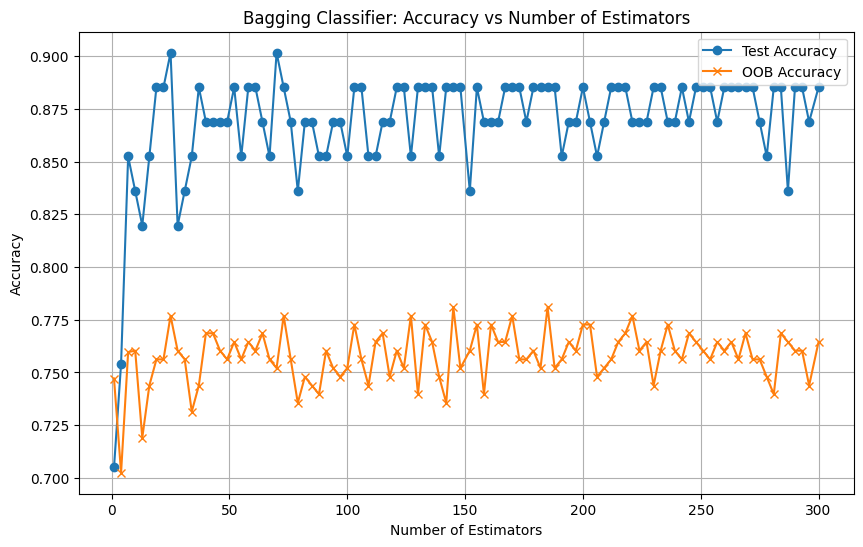

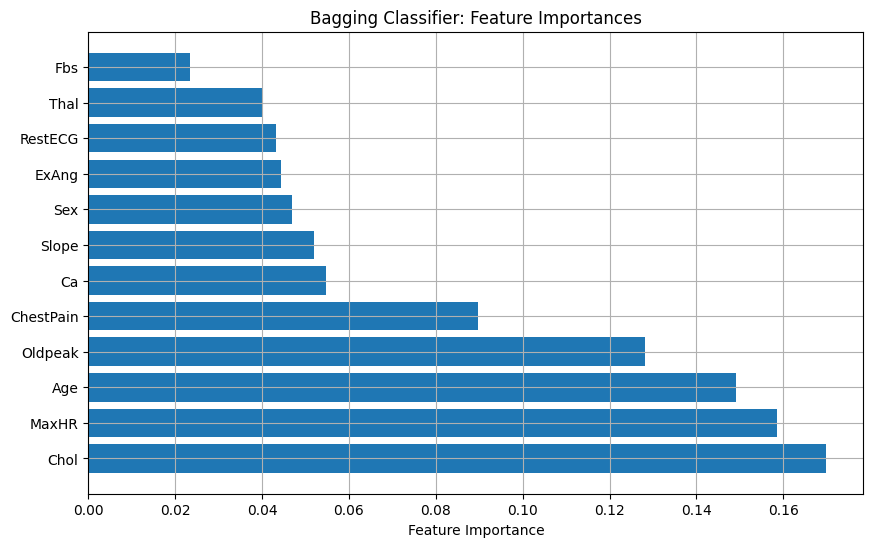

In [6]:
## Now lets use bagging to improve the classification performance on the heart disease dataset 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
# Load Heart Disease dataset
data = pd.read_csv('data/Heart.csv')
X = data[['Age', 'Chol', 'Sex', 'MaxHR', 'Oldpeak', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Ca', 'Thal']]
X = pd.get_dummies(X, columns=['ChestPain', 'RestECG', 'Slope', 'Thal'], drop_first=True).values # one-hot encode categorical features
y = data['AHD']  # binary target: No/Yes
y = np.where(y == 'Yes', 1, 0)  # convert to 0/1

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# Bagging Classifier
class BaggingClassifier:
    def __init__(self, n_estimators=10, max_depth=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
    def fit(self, X, y):
        self.trees = []
        self.bootstraps = []  # store indices used for each tree
        n_samples = len(X)
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            self.bootstraps.append(indices)  # store bootstrap indices
            X_sample, y_sample = X[indices], y[indices]
            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    def predict(self, X):
        # Collect predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        majority_votes = np.apply_along_axis(
            lambda x: np.bincount(x).argmax(), axis=0, arr=tree_preds
        )
        return majority_votes
    # add OOB score calculation
    def oob_score(self, X, y):
        n_samples = len(X)
        oob_votes = [[] for _ in range(n_samples)]  # list of votes for each sample

        for tree, indices in zip(self.trees, self.bootstraps):
            oob_indices = np.setdiff1d(np.arange(n_samples), indices)
            if len(oob_indices) == 0:
                continue
            preds = tree.predict(X[oob_indices])
            for idx, pred in zip(oob_indices, preds):
                oob_votes[idx].append(pred)

        # Aggregate OOB predictions
        final_oob_preds = np.zeros(n_samples)
        valid_mask = np.array([len(votes) > 0 for votes in oob_votes])
        for i, votes in enumerate(oob_votes):
            if votes:  # if there are any OOB votes
                final_oob_preds[i] = np.bincount(np.array(votes)).argmax()
            else:
                final_oob_preds[i] = -1  # mark samples never OOB
        valid_mask = final_oob_preds != -1
        oob_accuracy = np.mean(final_oob_preds[valid_mask] == y[valid_mask])
        return oob_accuracy
    
    # feature importance calculation
    def feature_importances_(self):
        """
        Compute impurity-based feature importances averaged over all trees.

        For classification, uses the total decrease in Gini impurity at each split.
        """
        n_features = X_train.shape[1]
        importances = np.zeros(n_features)

        for tree in self.trees:
            tree_imp = np.zeros(n_features)
            # sklearn DecisionTree stores all info in tree_.children_* and tree_.impurity
            t = tree.tree_
            # loop over all nodes
            for node in range(t.node_count):
                if t.children_left[node] != t.children_right[node]:  # split node
                    feature = t.feature[node]
                    if feature < 0:
                        continue
                    # weighted decrease in impurity
                    n_node_samples = t.n_node_samples[node]
                    left = t.children_left[node]
                    right = t.children_right[node]
                    n_left = t.n_node_samples[left]
                    n_right = t.n_node_samples[right]
                    impurity_decrease = (
                        t.impurity[node] -
                        (n_left / n_node_samples) * t.impurity[left] -
                        (n_right / n_node_samples) * t.impurity[right]
                    )
                    tree_imp[feature] += impurity_decrease
            importances += tree_imp

        # Average over all trees
        importances /= self.n_estimators
        # Normalize to sum to 1
        importances /= importances.sum()
        return importances


    
# Train Bagging Classifier
bagging_clf = BaggingClassifier(n_estimators=50, max_depth=None)
bagging_clf.fit(X_train, y_train)
# Predict on test set
y_pred = bagging_clf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Bagging Classifier Test Accuracy: {accuracy * 100:.2f}%")
# Calculate OOB score
oob_accuracy = bagging_clf.oob_score(X_train, y_train)
print(f"Bagging Classifier OOB Accuracy: {oob_accuracy * 100:.2f}%") 


# Now do the bagging with different number of estimators and plot the accuracy
#1- 300  estimators in 100 steps
n_estimators_list = np.linspace(1, 300, 100, dtype=int)
accuracies = []
oob_accuracies = []
for n_estimators in n_estimators_list:
    bagging_clf = BaggingClassifier(n_estimators=n_estimators, max_depth=None)
    bagging_clf.fit(X_train, y_train)
    oob_accuracy = bagging_clf.oob_score(X_train, y_train)
    oob_accuracies.append(oob_accuracy)
    y_pred = bagging_clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
# Plot accuracy vs number of estimators
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, accuracies, marker='o')
plt.plot(n_estimators_list, oob_accuracies, marker='x')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Bagging Classifier: Accuracy vs Number of Estimators')
plt.legend(['Test Accuracy', 'OOB Accuracy'])
plt.grid()
plt.show()

# now plot feature importances
# Train Bagging Classifier
bagging_clf = BaggingClassifier(n_estimators=100, max_depth=None)
bagging_clf.fit(X_train, y_train)
importances = bagging_clf.feature_importances_()
feature_names = data[['Age', 'Chol', 'Sex', 'MaxHR', 'Oldpeak', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Ca', 'Thal']].columns
# Get feature names after one-hot encoding
feature_names_full = pd.get_dummies(
    data[['Age', 'Chol', 'Sex', 'MaxHR', 'Oldpeak', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Ca', 'Thal']], 
    columns=['ChestPain', 'RestECG', 'Slope', 'Thal'], drop_first=True
).columns
# summarize importances for the one-hot encoded features into original feature names
importances_dict = {}
for name, imp in zip(feature_names_full, importances):
    base_name = name.split('_')[0]  # get the base feature name
    if base_name in importances_dict:
        importances_dict[base_name] += imp
    else:
        importances_dict[base_name] = imp
# normalize categorical feature importances
total_imp = sum(importances_dict.values())
for key in importances_dict:
    importances_dict[key] /= total_imp

# now sort the importances descending
importances_dict = dict(sorted(importances_dict.items(), key=lambda item: item[1], reverse=True))

feature_names = list(importances_dict.keys())
importances = np.array(list(importances_dict.values()))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Bagging Classifier: Feature Importances')
plt.grid()
plt.show()




## Random Forest

A key limitation of bagging with decision trees is that the individual trees are often **highly correlated**.  
Although each tree is trained on a different bootstrap sample, strong predictors tend to be selected at the top splits of many trees, causing them to learn **very similar decision boundaries**.

Random Forest addresses this limitation by introducing an additional source of randomness during tree construction.  
At **each split**, only a **random subset of the predictors** is considered as candidates for splitting.

Formally, if the total number of predictors is $p$, then at each split only $m < p$ predictors are randomly selected, and the best split is chosen among these $m$ variables.

Typical choices are:
- **Classification:** $m = \sqrt{p}$
- **Regression:** $m = p / 3$

All other aspects remain identical to bagging:
- Trees are grown on bootstrap samples
- Trees are grown deep (low bias, high variance)
- Predictions are aggregated by majority vote (classification) or averaging (regression)

By forcing different trees to consider different subsets of predictors, Random Forest produces **less correlated trees**, which leads to a stronger reduction in variance and typically improved predictive performance compared to bagging.
## Take-away

> **Bagging reduces variance by averaging many trees.  
Random Forest reduces variance more effectively by averaging *decorrelated* trees through random feature selection at each split.**

In practice, Random Forest almost always improves upon bagging when predictors are correlated or when strong predictors dominate early splits.

Random Forest Classifier Test Accuracy: 83.61%
Random Forest Classifier OOB Accuracy: 77.69%
Bagging Classifier Test Accuracy: 81.97%
Bagging Classifier OOB Accuracy: 75.21%


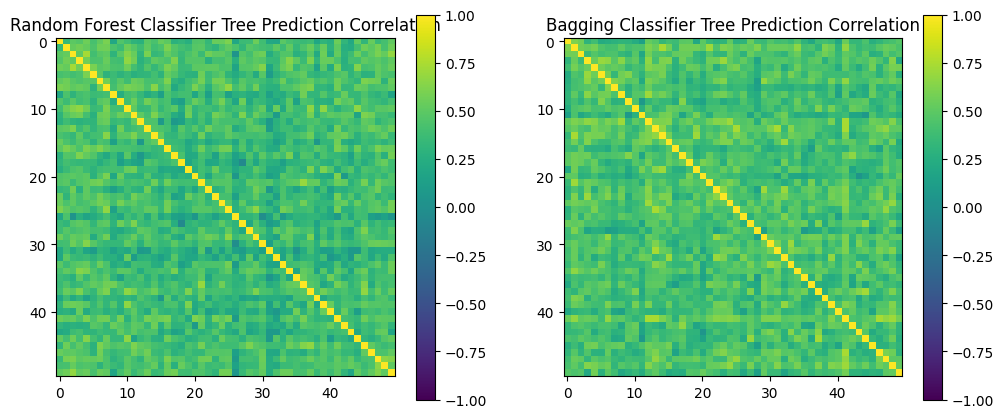

Mean tree correlation (Random Forest): 0.387
Mean tree correlation (Bagging):       0.420


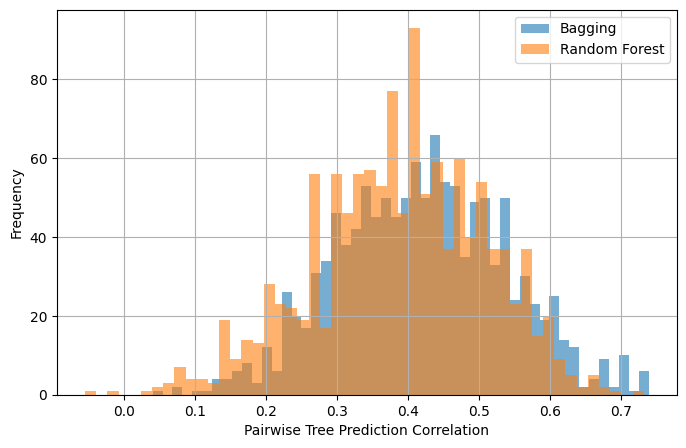

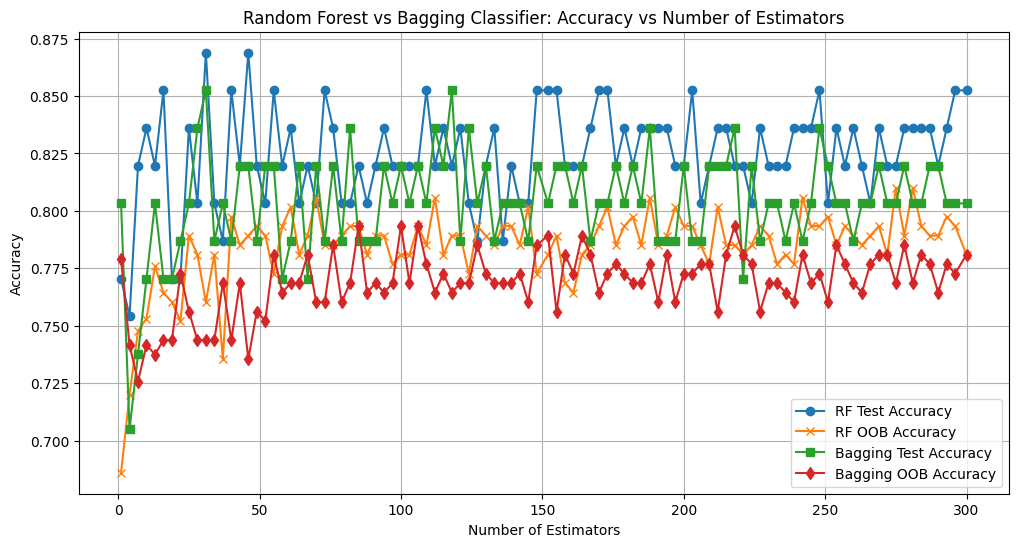

In [7]:
## Random forest implementation from scratch for regression tasks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Load Heart Disease dataset
data = pd.read_csv('data/Heart.csv')
X = data[['Age', 'Chol', 'Sex', 'MaxHR', 'Oldpeak', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Ca', 'Thal']]
X = pd.get_dummies(X, columns=['ChestPain', 'RestECG', 'Slope', 'Thal'], drop_first=True).values # one-hot encode categorical features
y = data['AHD']  # binary target: No/Yes
y = np.where(y == 'Yes', 1, 0)  # convert to 0/1

# fix the random seed for reproducibility
Seed = 41
np.random.seed(Seed)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=Seed
)




# Random Forest Classifier
class RandomForestClassifier:
    def __init__(self, n_estimators=10, max_depth=None, max_features="sqrt"):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
    def fit(self, X, y):
        self.trees = []
        self.bootstraps = []  # store indices used for each tree
        n_samples = len(X)
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            self.bootstraps.append(indices)  # store bootstrap indices
            X_sample, y_sample = X[indices], y[indices]
            # Use a decision tree with random feature selection at each split
            # Scikit-learn's DecisionTreeClassifier supports max_features parameter for this purpose
            tree = DecisionTreeClassifier(max_depth=self.max_depth, max_features=self.max_features, random_state=Seed) 
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    def predict(self, X):
        # Collect predictions from all trees
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Majority vote
        majority_votes = np.apply_along_axis(
            lambda x: np.bincount(x).argmax(), axis=0, arr=tree_preds
        )
        return majority_votes
    # add OOB score calculation
    def oob_score(self, X, y):
        n_samples = len(X)
        oob_votes = [[] for _ in range(n_samples)]  # list of votes for each sample

        for tree, indices in zip(self.trees, self.bootstraps):
            oob_indices = np.setdiff1d(np.arange(n_samples), indices)
            if len(oob_indices) == 0:
                continue
            preds = tree.predict(X[oob_indices])
            for idx, pred in zip(oob_indices, preds):
                oob_votes[idx].append(pred)

        # Aggregate OOB predictions
        final_oob_preds = np.zeros(n_samples)
        valid_mask = np.array([len(votes) > 0 for votes in oob_votes])
        for i, votes in enumerate(oob_votes):
            if votes:  # if there are any OOB votes
                final_oob_preds[i] = np.bincount(np.array(votes)).argmax()
            else:
                final_oob_preds[i] = -1  # mark samples never OOB
        valid_mask = final_oob_preds != -1
        oob_accuracy = np.mean(final_oob_preds[valid_mask] == y[valid_mask])
        return oob_accuracy
    
    # feature importance calculation
    def feature_importances_(self):
        """
        Compute impurity-based feature importances averaged over all trees.

        For classification, uses the total decrease in Gini impurity at each split.
        """
        n_features = X_train.shape[1]
        importances = np.zeros(n_features)

        for tree in self.trees:
            tree_imp = np.zeros(n_features)
            # sklearn DecisionTree stores all info in tree_.children_* and tree_.impurity
            t = tree.tree_
            # loop over all nodes
            for node in range(t.node_count):
                if t.children_left[node] != t.children_right[node]:  # split node
                    feature = t.feature[node]
                    if feature < 0:
                        continue
                    # weighted decrease in impurity
                    n_node_samples = t.n_node_samples[node]
                    left = t.children_left[node]
                    right = t.children_right[node]
                    n_left = t.n_node_samples[left]
                    n_right = t.n_node_samples[right]
                    impurity_decrease = (
                        t.impurity[node] -
                        (n_left / n_node_samples) * t.impurity[left] -
                        (n_right / n_node_samples) * t.impurity[right]
                    )
                    tree_imp[feature] += impurity_decrease
            importances += tree_imp

        # Average over all trees
        importances /= self.n_estimators
        # Normalize to sum to 1
        importances /= importances.sum()
        return importances
    
# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=None, max_features="sqrt")
rf_clf.fit(X_train, y_train)
# Predict on test set
y_pred = rf_clf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Test Accuracy: {accuracy * 100:.2f}%")
# Calculate OOB score
oob_accuracy = rf_clf.oob_score(X_train, y_train)
print(f"Random Forest Classifier OOB Accuracy: {oob_accuracy * 100:.2f}%")

# Train as comparison a bagging classifier
bagging_clf = BaggingClassifier(n_estimators=50, max_depth=None)
bagging_clf.fit(X_train, y_train)
# Predict on test set
y_pred = bagging_clf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Bagging Classifier Test Accuracy: {accuracy * 100:.2f}%")
# Calculate OOB score
oob_accuracy = bagging_clf.oob_score(X_train, y_train)
print(f"Bagging Classifier OOB Accuracy: {oob_accuracy * 100:.2f}%")

# Assess the correlation between individual tree predictions in the random forest
n_trees = len(rf_clf.trees)
tree_preds = np.array([tree.predict(X_test) for tree in rf_clf.trees])
correlation_matrix_rfc = np.corrcoef(tree_preds)
# Compute correlation matrix for bagging classifier
tree_preds_bagging = np.array([tree.predict(X_test) for tree in bagging_clf.trees])
correlation_matrix_bagging = np.corrcoef(tree_preds_bagging)

# now make 2 subplots to compare the correlation matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(correlation_matrix_rfc, cmap='viridis', vmin=-1, vmax=1)
plt.title('Random Forest Classifier Tree Prediction Correlation')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(correlation_matrix_bagging, cmap='viridis', vmin=-1, vmax=1)
plt.title('Bagging Classifier Tree Prediction Correlation')
plt.colorbar()
plt.show()

def mean_off_diagonal_corr(C):
    n = C.shape[0]
    return (np.sum(C) - np.trace(C)) / (n * (n - 1))


mean_corr_rf = mean_off_diagonal_corr(correlation_matrix_rfc)
mean_corr_bagging = mean_off_diagonal_corr(correlation_matrix_bagging)

print(f"Mean tree correlation (Random Forest): {mean_corr_rf:.3f}")
print(f"Mean tree correlation (Bagging):       {mean_corr_bagging:.3f}")

def off_diagonal_values(C):
    return C[np.triu_indices_from(C, k=1)]

rf_vals = off_diagonal_values(correlation_matrix_rfc)
bag_vals = off_diagonal_values(correlation_matrix_bagging)
plt.figure(figsize=(8,5))
plt.hist(bag_vals, bins=50, alpha=0.6, label="Bagging")
plt.hist(rf_vals, bins=50, alpha=0.6, label="Random Forest")
plt.xlabel("Pairwise Tree Prediction Correlation")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

# now step over different number of estimators and plot the accuracy
n_estimators_list = np.linspace(1, 300, 100, dtype=int)
accuracies_rf = []
oob_accuracies_rf = []
accuracies_bagging = []
oob_accuracies_bagging = []

for n_estimators in n_estimators_list:
    # Random Forest
    rf_clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=None, max_features="sqrt")
    rf_clf.fit(X_train, y_train)
    oob_accuracy = rf_clf.oob_score(X_train, y_train)
    oob_accuracies_rf.append(oob_accuracy)
    y_pred = rf_clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies_rf.append(accuracy)
    # Bagging
    bagging_clf = BaggingClassifier(n_estimators=n_estimators, max_depth=None)
    bagging_clf.fit(X_train, y_train)
    oob_accuracy = bagging_clf.oob_score(X_train, y_train)
    oob_accuracies_bagging.append(oob_accuracy)
    y_pred = bagging_clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies_bagging.append(accuracy)
# Plot accuracy vs number of estimators
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_list, accuracies_rf, marker='o')
plt.plot(n_estimators_list, oob_accuracies_rf, marker='x')
plt.plot(n_estimators_list, accuracies_bagging, marker='s')
plt.plot(n_estimators_list, oob_accuracies_bagging, marker='d')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest vs Bagging Classifier: Accuracy vs Number of Estimators')
plt.legend(['RF Test Accuracy', 'RF OOB Accuracy', 'Bagging Test Accuracy', 'Bagging OOB Accuracy'])
plt.grid()
plt.show()


# Boosting (Gradient Boosting)

Boosting differs from bagging in that the base learners (e.g., decision trees) are **not trained independently in parallel**, but **sequentially**.  
Instead of fitting each tree to a bootstrap sample of the data, boosting fits each tree to the **entire training set**, where each successive tree focuses on the **errors made by the current ensemble**.

In gradient boosting for regression with squared error loss, each tree (except the first) is trained on the **residuals**

$$
r_i^{(m)} = y_i - f_{m-1}(x_i),
$$

i.e., the part of the response not yet explained by the current model.  
More generally, gradient boosting fits trees to the **negative gradient of the loss function**.

To control model complexity and improve generalization, a **shrinkage (learning rate) parameter** $\nu \in (0,1]$ is introduced, which scales the contribution of each new tree.

---

## Hyperparameters

1. **Shrinkage / learning rate** $\nu$ (typical values: $0.001$–$0.1$)  
2. **Number of trees** $B$  
3. **Tree depth** $d$ (typically $d = 1$–$3$ for boosting)

Small $\nu$ values require larger $B$, but often lead to better generalization.

---

## Comparison with Bagging

**Bagging**
- Trees are trained independently on bootstrap samples
- Trees are typically grown deep
- Main goal: **variance reduction**
- No interaction between trees

**Boosting**
- Trees are trained sequentially on the full dataset
- Trees are typically shallow
- Main goal: **bias reduction**
- Each tree corrects the errors of the previous ensemble

> Bagging averages many high-variance models,  
> Boosting builds a strong model by sequentially correcting mistakes.

---

## Gradient Boosting Algorithm 

Given training data $\{(x_i, y_i)\}_{i=1}^N$ and a differentiable loss function $L(y, f(x))$:

1. Initialize the model with a constant prediction:
$$
f_0(x) = \arg\min_c \sum_{i=1}^N L(y_i, c)
$$

2. For $m = 1, \dots, B$:
   - Compute pseudo-residuals:
$$
r_i^{(m)} = -\left.\frac{\partial L(y_i, f(x_i))}{\partial f(x_i)}\right|_{f = f_{m-1}}
$$
   - Fit a regression tree $h_m(x)$ to $\{(x_i, r_i^{(m)})\}$  
   - Update the model:
$$
f_m(x) = f_{m-1}(x) + \nu h_m(x)
$$

3. Output $f_B(x)$

---

## Detailed Description of Each Step

**Initialization**  
For squared error loss, the initial model is simply the mean of $y$:
$$
f_0(x) = \bar y
$$

**Residual / Gradient Computation**  
For squared error loss,
$$
L(y, f(x)) = (y - f(x))^2,
$$
the negative gradient equals the residual:
$$
r_i^{(m)} = y_i - f_{m-1}(x_i)
$$

**Tree Fitting**  
Each tree is a weak learner that approximates the residual structure left unexplained by the current ensemble.

**Shrinkage**  
The learning rate $\nu$ ensures that each update is small:
- prevents overfitting
- increases robustness
- encourages gradual improvement

**Final Prediction**  
The final model is an additive expansion:
$$
f_B(x) = \sum_{m=0}^B \nu h_m(x)
$$

---

## 4. Difference to AdaBoost

| Aspect | Gradient Boosting | AdaBoost |
|------|------------------|----------|
| Target | Residuals / gradients | Reweighted observations |
| Loss function | Arbitrary differentiable loss | Exponential loss |
| Sample weights | Not explicit | Explicitly updated |
| Output | Additive model | Weighted majority vote |

AdaBoost increases the weights of misclassified observations, whereas gradient boosting directly fits the **functional gradient** of a loss function.

---

## 5. Summary and Take-away

- Boosting builds models **sequentially**, not independently  
- Each tree focuses on **what previous trees failed to explain**  
- Shrinkage $\nu$ is crucial for generalization  
- Shallow trees + many iterations work best  
- Gradient boosting generalizes AdaBoost by framing boosting as **functional gradient descent**

> **Boosting converts many weak learners into a strong learner by iteratively correcting residual errors using small, controlled updates.**


Gradient Boosting Regressor Validation MSE: 0.2590
Gradient Boosting Regressor Training MSE: 0.0457
Gradient Boosting Regressor Validation RMSE: 1.66 in original salary scale


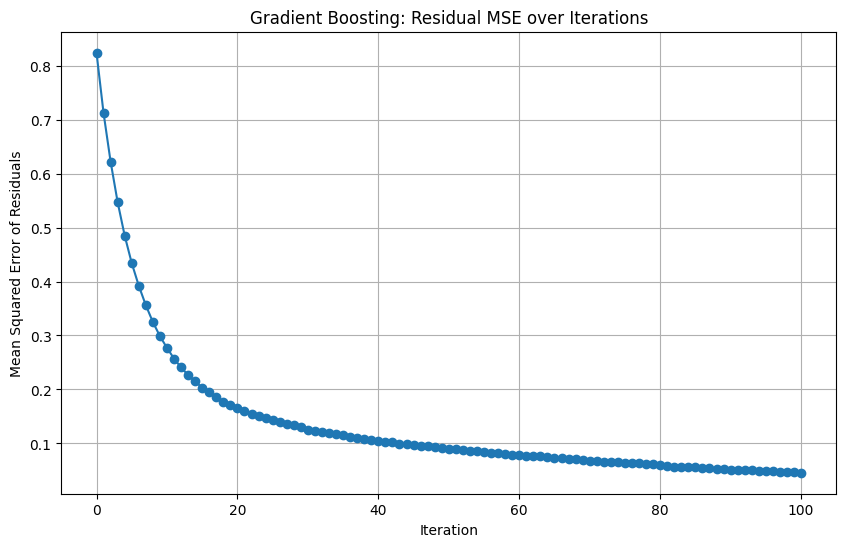

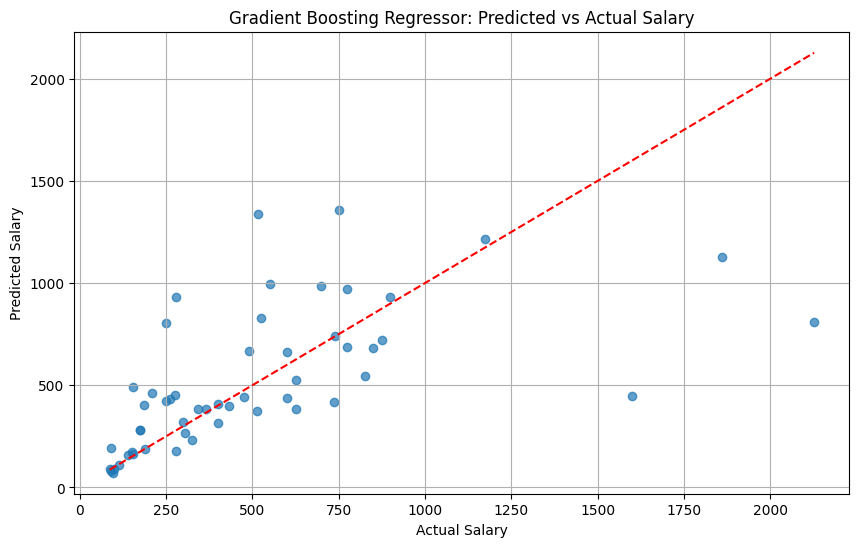

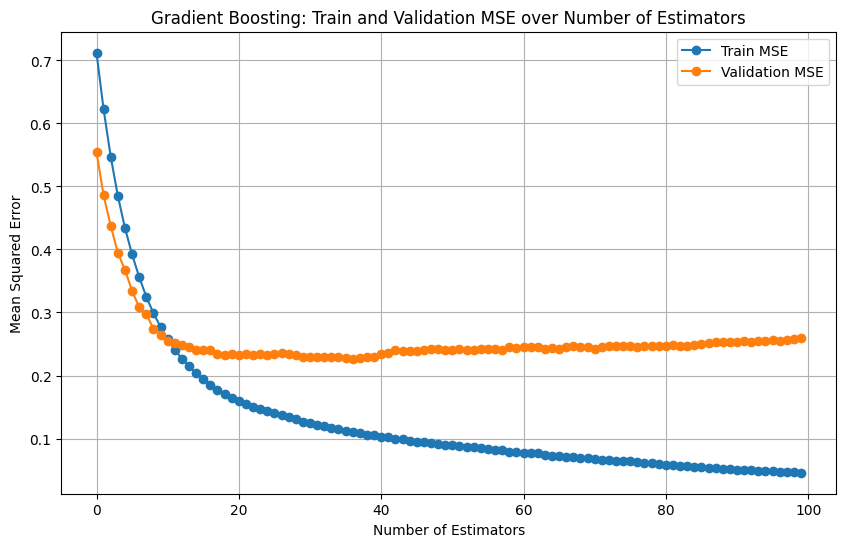

In [8]:
## Gradient Boosting Implementation from Scratch for Regression Tasks using the Hitters dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
# Load Hitters dataset
hitters = pd.read_csv('data/Hitters.csv').dropna()
X = hitters[['Years', 'Hits', 'HmRun', 'Runs', 'RBI']].values
y = np.log(hitters['Salary'].values)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Gradient Boosting Regressor
class GradientBoostingRegressor:
    def __init__(self, n_estimators=100, lambda_lr=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.lambda_lr = lambda_lr
        self.max_depth = max_depth
        self.trees = []
        self.initial_prediction = None
    def fit(self, X, y):
        # Initialize model with mean prediction
        self.initial_prediction = np.mean(y) # F_0(x) = mean(y)
        residuals = y - self.initial_prediction # r_i = y_i - F_0(x_i)
        self.residuals_history = [residuals.copy()]
        for _ in range(self.n_estimators):
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals) # fit f_i(x) to residuals
            predictions = tree.predict(X) # f_i(x_i) the new "y_hat"
            residuals -= self.lambda_lr * predictions # update residuals: r_i = r_i - lambda * f_i(x_i)
            self.residuals_history.append(residuals.copy()) # log residuals
            self.trees.append(tree)
    def predict(self, X):
        y_pred = np.full(X.shape[0], self.initial_prediction)
        for tree in self.trees: # F_M(x) = F_0(x) + lambda * sum f_i(x)
            y_pred += self.lambda_lr * tree.predict(X)
        return y_pred
    
# Train Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, lambda_lr=0.1, max_depth=3)
gb_reg.fit(X_train, y_train)
# Predict on validation set
y_pred = gb_reg.predict(X_val)
# Calculate MSE on validation set
mse = mean_squared_error(y_val, y_pred)
print(f"Gradient Boosting Regressor Validation MSE: {mse:.4f}")
# Calculate MSE on training set
y_train_pred = gb_reg.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
print(f"Gradient Boosting Regressor Training MSE: {train_mse:.4f}")
# print accuracy of the model in terms of exp of mse
rmse = np.sqrt(mse)
print(f"Gradient Boosting Regressor Validation RMSE: {np.exp(rmse):.2f} in original salary scale")
# plot the residuals over iterations
plt.figure(figsize=(10, 6))
# plot the error decay over iterations
mse_list = [np.mean(res**2) for res in gb_reg.residuals_history]
plt.plot(mse_list, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error of Residuals')
plt.title('Gradient Boosting: Residual MSE over Iterations')
plt.grid()
plt.show()

# Plot predicted vs actual salaries
plt.figure(figsize=(10, 6))
plt.scatter(np.exp(y_val), np.exp(y_pred), alpha=0.7)
plt.plot([np.exp(y_val).min(), np.exp(y_val).max()], [np.exp(y_val).min(), np.exp(y_val).max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Gradient Boosting Regressor: Predicted vs Actual Salary')
plt.grid()
plt.show()

# plot how test and train mse evolve with number of estimators
train_mse_list = []
val_mse_list = []
for i in range(1, gb_reg.n_estimators + 1):
    y_train_pred = gb_reg.initial_prediction + gb_reg.lambda_lr * np.sum(
        [tree.predict(X_train) for tree in gb_reg.trees[:i]], axis=0
    )
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mse_list.append(train_mse)
    y_val_pred = gb_reg.initial_prediction + gb_reg.lambda_lr * np.sum(
        [tree.predict(X_val) for tree in gb_reg.trees[:i]], axis=0
    )
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_mse_list.append(val_mse)
# plot the error decay over iterations
plt.figure(figsize=(10, 6))
plt.plot(train_mse_list, label='Train MSE', marker='o')
plt.plot(val_mse_list, label='Validation MSE', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Boosting: Train and Validation MSE over Number of Estimators')
plt.legend()
plt.grid()
plt.show()

    

## AdaBoost (Adaptive Boosting) — Classification

AdaBoost is a **boosting algorithm for classification** that builds an additive model by sequentially fitting weak learners (typically decision stumps) to **reweighted versions of the training data**.  
Unlike bagging, learners are trained **sequentially**, and unlike gradient boosting, AdaBoost focuses on **reweighting observations**, not fitting residuals.

AdaBoost was originally formulated for **binary classification** with labels  
$y_i \in \{-1, +1\}$.


## Algorithm Overview

**Goal:**  
Construct a strong classifier as a weighted sum of weak classifiers.

**Training data:**  
$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n, \quad y_i \in \{-1, +1\}
$$

**Model form (additive):**
$$
F_M(x) = \sum_{m=1}^M \alpha_m h_m(x)
$$

Final prediction:
$$
H(x) = \operatorname{sign}(F_M(x))
$$

## AdaBoost Algorithm (Step-by-Step, ISL-style)

### Step 0: Initialize sample weights
All observations start with equal weight:
$$
w_i^{(1)} = \frac{1}{n}, \quad i = 1, \dots, n
$$

### Step 1: Iterate for $m = 1, \dots, M$

#### 1. Fit a weak learner
Train a classifier $h_m(x)$ using the **current sample weights** $w_i^{(m)}$.

---

#### Step 2. Compute the weighted classification error
$$
\varepsilon_m
= \frac{\sum_{i=1}^n w_i^{(m)} \mathbf{1}\{y_i \neq h_m(x_i)\}}
       {\sum_{i=1}^n w_i^{(m)}}
$$

A weak learner must satisfy:
$$
\varepsilon_m < 0.5
$$

---

#### Step 3. Compute the learner weight
$$
\alpha_m
= \frac{1}{2} \log\!\left(\frac{1 - \varepsilon_m}{\varepsilon_m}\right)
$$

- Better classifiers receive larger $\alpha_m$
- Poor classifiers receive smaller $\alpha_m$

---

#### Step 4. Update sample weights
$$
w_i^{(m+1)}
= w_i^{(m)} \exp\!\left(-\alpha_m y_i h_m(x_i)\right)
$$

- Misclassified samples ($y_i \neq h_m(x_i)$) get **upweighted**
- Correctly classified samples get **downweighted**

Normalize:
$$
\sum_{i=1}^n w_i^{(m+1)} = 1
$$

---

## Interpretation

- AdaBoost **focuses learning on hard-to-classify observations**
- Each new classifier corrects the mistakes of the previous ensemble
- The model is a **forward stagewise additive model**
- AdaBoost minimizes an **exponential loss function**

## Relation to Gradient Boosting

AdaBoost can be interpreted as a **special case of gradient boosting** using the exponential loss:
$$
L(y, F(x)) = \exp(-y F(x))
$$

However, the algorithms differ operationally.

## AdaBoost vs. Gradient Boosting

| Aspect | AdaBoost | Gradient Boosting |
|------|---------|------------------|
| Task | Classification | Regression & classification |
| Targets | Class labels | Pseudo-residuals |
| Data handling | Reweights observations | Fits residuals |
| Loss function | Exponential (fixed) | Arbitrary (user-defined) |
| Learning rate | Implicit via $\alpha_m$ | Explicit shrinkage $\lambda$ |
| Robustness to outliers | Low | Higher (loss-dependent) |

## Key Differences in Intuition

- **AdaBoost:**  
  “Pay more attention to observations that were misclassified.”

- **Gradient Boosting:**  
  “Fit a model to the negative gradient of the loss.”

## Summary and Take-away

> **AdaBoost is a classification-only boosting algorithm that improves performance by reweighting misclassified observations, while Gradient Boosting is a general framework that fits residuals (gradients) for arbitrary loss functions.**

In practice:
- AdaBoost works well with **simple weak learners**
- Gradient Boosting offers **greater flexibility and robustness**
- Modern implementations often prefer Gradient Boosting for regression and noisy data

AdaBoost Classifier Test Accuracy: 83.61%


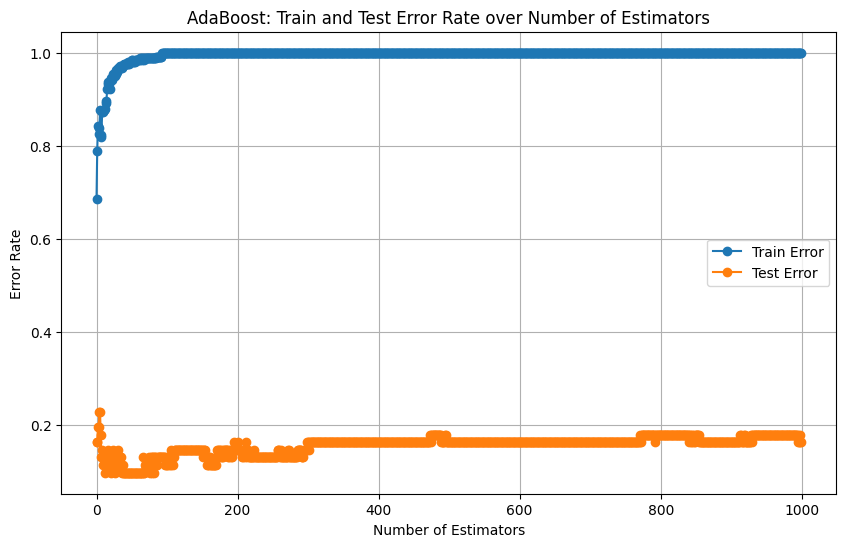

In [9]:
### Implementation of AdaBoost from scratch for binary classification of the Heart Disease dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# Load Heart Disease dataset
data = pd.read_csv('data/Heart.csv')
X = data[['Age', 'Chol', 'Sex', 'MaxHR', 'Oldpeak', 'ChestPain', 'Fbs', 'RestECG', 'ExAng', 'Slope', 'Ca', 'Thal']]
X = pd.get_dummies(X, columns=['ChestPain', 'RestECG', 'Slope', 'Thal'], drop_first=True).values # one-hot encode categorical features
y = data['AHD']  # binary target: No/Yes
# AdaBoost is defined for labels y ∈ {−1, +1}; this avoids ad-hoc conversions and matches the ISL weight-update formula exactly.
y = np.where(y == 'Yes', 1, -1)  # {-1, +1}
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# AdaBoost Classifier
class AdaBoostClassifier:
    def __init__(self, n_estimators=50, max_depth=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        self.alphas = []
    def fit(self, X, y):
        n_samples = len(X)
        # Initialize weights uniformly
        weights = np.full(n_samples, 1 / n_samples)
        for _ in range(self.n_estimators):
            tree = DecisionTreeClassifier(criterion='gini', max_depth=self.max_depth)
            tree.fit(X, y, sample_weight=weights)
            predictions = tree.predict(X)
            # Compute weighted error
            misclassified = (predictions != y)
            error = np.sum(weights * misclassified) / np.sum(weights)
            # Avoid division by zero
            error = np.clip(error, 1e-10, 1 - 1e-10)
            # Compute alpha
            alpha = 0.5 * np.log((1 - error) / error)
            # Update weights
            weights *= np.exp(-alpha * y * predictions)
            # y in {0,1} to {-1,1}
            weights /= np.sum(weights) # normalize
            self.trees.append(tree)
            self.alphas.append(alpha)
    def predict(self, X):
        final_pred = np.zeros(X.shape[0])
        for tree, alpha in zip(self.trees, self.alphas):
            predictions = tree.predict(X)
            final_pred += alpha * predictions
        return np.sign(final_pred) # convert back to {-1, +1} to match training labels

    
# Train AdaBoost Classifier
adb_clf = AdaBoostClassifier(n_estimators=1000, max_depth=1)
adb_clf.fit(X_train, y_train)
# Predict on test set
y_pred = adb_clf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classifier Test Accuracy: {accuracy * 100:.2f}%")

# Plot training error over iterations
train_errors = []
test_errors = []
for i in range(1, adb_clf.n_estimators + 1):
    y_train_pred = np.zeros(X_train.shape[0])
    for tree, alpha in zip(adb_clf.trees[:i], adb_clf.alphas[:i]):
        predictions = tree.predict(X_train)
        y_train_pred += alpha * (2 * predictions - 1)
    y_train_pred = (y_train_pred > 0).astype(int)
    error = 1 - accuracy_score(y_train, y_train_pred)
    train_errors.append(error)#
    y_test_pred = np.zeros(X_test.shape[0])
    for tree, alpha in zip(adb_clf.trees[:i], adb_clf.alphas[:i]):
        predictions = tree.predict(X_test)
        y_test_pred += alpha * predictions
    y_test_pred = np.sign(y_test_pred)
    error = 1 - accuracy_score(y_test, y_test_pred)
    test_errors.append(error)
# plot the error decay over iterations
plt.figure(figsize=(10, 6))
plt.plot(train_errors, marker='o')
plt.plot(test_errors, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Error Rate')
plt.title('AdaBoost: Train and Test Error Rate over Number of Estimators')
plt.legend(['Train Error', 'Test Error'])
plt.grid()
plt.show()


# Further Reading: Tree-Based Methods and Ensemble Learning  

This section lists **standard and canonical references** for decision trees, bagging, random forests, boosting, and ensemble learning.

---

## 1. Core Textbooks (Essential)

### 1.1 *An Introduction to Statistical Learning: With Applications in R*  
**Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani**

- Decision Trees
- Bagging
- Random Forests
- Boosting (AdaBoost, Gradient Boosting)
- Bias–Variance Tradeoff, OOB error, Variable Importance

> Best conceptual entry point.

---

### 1.2 *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*  
**Trevor Hastie, Robert Tibshirani, Jerome Friedman**

- CART
- Bagging
- Random Forests
- AdaBoost
- Gradient Boosting as functional gradient descent

> Canonical theoretical reference.

---

## 2. Decision Trees and Random Forests

### 2.1 *Classification and Regression Trees*  
**Leo Breiman, Jerome Friedman, Richard Olshen, Charles Stone (1984)**

- Tree growing and pruning
- Gini index, RSS
- Cost-complexity pruning
- Variable importance

> Foundational tree methodology (CART).

---

### 2.2 *Random Forests*  
**Leo Breiman (2001), Machine Learning**

- Bootstrap aggregation
- Random feature selection
- Out-of-bag (OOB) error
- Variable importance

> Original Random Forest paper.

---

## 3. Boosting

### 3.1 *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*  
**Yoav Freund, Robert E. Schapire (1997), Journal of Computer and System Sciences**

- AdaBoost algorithm
- Exponential loss
- Margin-based interpretation

> Foundational AdaBoost paper.

---

### 3.2 *Greedy Function Approximation: A Gradient Boosting Machine*  
**Jerome H. Friedman (2001), Annals of Statistics**

- Boosting as gradient descent in function space
- General loss functions
- Shrinkage and regularization

> Core reference for Gradient Boosting.

---

### 3.3 *Stochastic Gradient Boosting*  
**Jerome H. Friedman (2002)**

- Subsampling in gradient boosting
- Variance reduction
- Improved generalization

---

## 4. Ensemble Learning (General Perspective)

### 4.1 *Ensemble Methods in Machine Learning*  
**Thomas G. Dietterich (2000), Multiple Classifier Systems**

- Bias–variance decomposition
- Comparison of bagging, boosting, and randomization

---

### 4.2 *Ensemble Methods: Foundations and Algorithms*  
**Zhi-Hua Zhou (2012)**

- Diversity and ensemble error
- Theoretical guarantees
- Unified framework for ensemble methods

> Comprehensive modern reference.

---

## 5. Modern Tree Boosting Systems

### 5.1 *XGBoost: A Scalable Tree Boosting System*  
**Tianqi Chen, Carlos Guestrin (2016), KDD**

- Regularized gradient boosting
- Column subsampling
- Practical system design

---

### 5.2 *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*  
**Guolin Ke et al. (2017), NeurIPS**

- Histogram-based splits
- Leaf-wise tree growth
- Large-scale efficiency

---

### 5.3 *CatBoost: Unbiased Boosting with Categorical Features*  
**Liudmila Prokhorenkova et al. (2018), NeurIPS**

- Ordered boosting
- Native categorical handling
- Reduced prediction shift

---

## Suggested Reading Order

1. *An Introduction to Statistical Learning*  
2. *Classification and Regression Trees*  
3. *Random Forests* (Breiman, 2001)  
4. *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*  
5. *Greedy Function Approximation: A Gradient Boosting Machine*  
6. *The Elements of Statistical Learning*  
7. XGBoost / LightGBM / CatBoost papers

---

## Take-away

> Tree-based ensemble methods form a **unified framework** addressing variance reduction, model correlation, and functional optimization rather than isolated algorithms.
